# What drives the price of a used car?


### OVERVIEW

In this application, you will explore a dataset from kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing. Your goal is to understand what factors make a car more or less expensive. As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### Business Understanding
From a business perspective, we are tasked with identifying key drivers for used car prices. In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition. Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")


In [ ]:
data = pd.read_csv(r"vehicles.csv")
data.tail(10)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
426870,7301592119,wyoming,22990,2020.0,hyundai,sonata se sedan 4d,good,NaN,gas,3066.0,clean,other,5NPEG4JAXLH051710,fwd,NaN,sedan,blue,wy
426871,7301591639,wyoming,17990,2018.0,kia,sportage lx sport utility 4d,good,NaN,gas,34239.0,clean,other,KNDPMCAC7J7417329,NaN,NaN,SUV,NaN,wy
426872,7301591201,wyoming,32590,2020.0,mercedes-benz,c-class c 300,good,NaN,gas,19059.0,clean,other,55SWF8DB6LU325050,rwd,NaN,sedan,white,wy
426873,7301591202,wyoming,30990,2018.0,mercedes-benz,glc 300 sport,good,NaN,gas,15080.0,clean,automatic,WDC0G4JB6JV019749,rwd,NaN,other,white,wy
426874,7301591199,wyoming,33590,2018.0,lexus,gs 350 sedan 4d,good,6 cylinders,gas,30814.0,clean,automatic,JTHBZ1BLXJA012999,rwd,NaN,sedan,white,wy
426875,7301591192,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,wy
426876,7301591187,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,wy
426877,7301591147,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,wy
426878,7301591140,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,wy
426879,7301591129,wyoming,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,gas,22716.0,clean,other,WBA4J1C58KBM14708,rwd,NaN,coupe,NaN,wy


### Data Understanding
After considering the business understanding, we want to get familiar with our data. Write down some steps that you would take to get to know the dataset and identify any quality issues within. Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [ ]:
data.shape


(426880, 18)

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [ ]:
data.isnull().sum()


id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

In [ ]:
for col in data.columns:
    print(f"\nColumn: {col}")
    print(data[col].unique()[:10])



Column: id
[7222695916 7218891961 7221797935 7222270760 7210384030 7222379453
 7221952215 7220195662 7209064557 7219485069]

Column: region
['prescott' 'fayetteville' 'florida keys' 'worcester / central MA'
 'greensboro' 'hudson valley' 'medford-ashland' 'erie' 'el paso'
 'bellingham']

Column: price
[ 6000 11900 21000  1500  4900  1600  1000 15995  5000  3000]

Column: year
[  nan 2014. 2010. 2020. 2017. 2013. 2012. 2016. 2019. 2011.]

Column: manufacturer
[nan 'gmc' 'chevrolet' 'toyota' 'ford' 'jeep' 'nissan' 'ram' 'mazda'
 'cadillac']

Column: model


[nan 'sierra 1500 crew cab slt' 'silverado 1500' 'silverado 1500 crew'
 'tundra double cab sr' 'f-150 xlt' 'sierra 2500 hd extended cab'
 'silverado 1500 double' 'tacoma' 'colorado extended cab']

Column: condition
[nan 'good' 'excellent' 'fair' 'like new' 'new' 'salvage']

Column: cylinders
[nan '8 cylinders' '6 cylinders' '4 cylinders' '5 cylinders' 'other'
 '3 cylinders' '10 cylinders' '12 cylinders']

Column: fuel
[nan 'gas' 'other' 'diesel' 'hybrid' 'electric']

Column: odometer
[    nan  57923.  71229.  19160.  41124. 128000.  68696.  29499.  43000.
  17302.]

Column: title_status
[nan 'clean' 'rebuilt' 'lien' 'salvage' 'missing' 'parts only']

Column: transmission
[nan 'other' 'automatic' 'manual']

Column: VIN
[nan '3GTP1VEC4EG551563' '1GCSCSE06AZ123805' '3GCPWCED5LG130317'
 '5TFRM5F17HX120972' '1GT220CG8CZ231238' '1GCVKREH6GZ228691'
 '1GCHTCE37G1186784' '1G1YR3DW3B5102190' '1C4BJWDG5HL705371']

Column: drive
[nan 'rwd' '4wd' 'fwd']

Column: size
[nan 'full-size' 'mid-size' 'co

In [ ]:
data = data.drop(columns=["id", "region", "VIN", "size", "state"])


In [ ]:
Main_df = pd.DataFrame(data)


In [ ]:
Main_df = Main_df.sample(n=2500, random_state=69)


In [ ]:
Main_df.head()


,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color
207157,6000,2005.0,volkswagen,passat wagon,good,6 cylinders,gas,112000.0,clean,automatic,fwd,wagon,black
127272,31646,2020.0,chevrolet,blazer lt,NaN,NaN,gas,5267.0,clean,automatic,NaN,NaN,NaN
403284,19797,2018.0,honda,hr-v,NaN,4 cylinders,gas,23024.0,clean,automatic,4wd,wagon,green
284695,7500,2010.0,honda,pilot ex-l,good,6 cylinders,gas,180000.0,clean,automatic,4wd,SUV,NaN
171186,11900,2012.0,honda,cr-v,excellent,4 cylinders,gas,79586.0,rebuilt,automatic,4wd,SUV,NaN


In [ ]:
Main_df.shape


(2500, 13)

In [ ]:
Main_df.isnull().sum()


price              0
year               8
manufacturer     113
model             19
condition        998
cylinders       1022
fuel              23
odometer          28
title_status      48
transmission      17
drive            770
type             508
paint_color      734
dtype: int64

# Handling missings values

In [ ]:
for col in Main_df.columns:
    if Main_df[col].isnull().any():
        if Main_df[col].dtype == "int64" or Main_df[col].dtype == "float64":
            median = Main_df[col].median()
            Main_df[col].fillna(median, inplace=True)
        elif Main_df[col].dtype == "object":
            mode = Main_df[col].mode()[0]
            Main_df[col].fillna(mode, inplace=True)

Main_df.isnull().sum()


price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
dtype: int64

In [ ]:
Main_df.dtypes


price             int64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
drive            object
type             object
paint_color      object
dtype: object

In [ ]:
Main_df.head()


,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color
207157,6000,2005.0,volkswagen,passat wagon,good,6 cylinders,gas,112000.0,clean,automatic,fwd,wagon,black
127272,31646,2020.0,chevrolet,blazer lt,good,6 cylinders,gas,5267.0,clean,automatic,4wd,sedan,white
403284,19797,2018.0,honda,hr-v,good,4 cylinders,gas,23024.0,clean,automatic,4wd,wagon,green
284695,7500,2010.0,honda,pilot ex-l,good,6 cylinders,gas,180000.0,clean,automatic,4wd,SUV,white
171186,11900,2012.0,honda,cr-v,excellent,4 cylinders,gas,79586.0,rebuilt,automatic,4wd,SUV,white


In [ ]:
numeric_columns = Main_df.select_dtypes(include=[int, float])
numeric_columns


,price,year,odometer
207157,6000,2005.0,112000.0
127272,31646,2020.0,5267.0
403284,19797,2018.0,23024.0
284695,7500,2010.0,180000.0
171186,11900,2012.0,79586.0
...,...,...,...
170659,36590,2018.0,32409.0
289197,19590,2015.0,40495.0
328931,5250,2009.0,81219.0
136989,19997,2018.0,14541.0


In [ ]:
categorical_columns = Main_df.select_dtypes(include=object)
categorical_columns


,manufacturer,model,condition,cylinders,fuel,title_status,transmission,drive,type,paint_color
207157,volkswagen,passat wagon,good,6 cylinders,gas,clean,automatic,fwd,wagon,black
127272,chevrolet,blazer lt,good,6 cylinders,gas,clean,automatic,4wd,sedan,white
403284,honda,hr-v,good,4 cylinders,gas,clean,automatic,4wd,wagon,green
284695,honda,pilot ex-l,good,6 cylinders,gas,clean,automatic,4wd,SUV,white
171186,honda,cr-v,excellent,4 cylinders,gas,rebuilt,automatic,4wd,SUV,white
...,...,...,...,...,...,...,...,...,...,...
170659,audi,q5 prestige sport utility,good,6 cylinders,gas,clean,other,4wd,SUV,red
289197,volkswagen,golf sportwagen tdi,good,6 cylinders,other,clean,other,fwd,wagon,white
328931,chevrolet,cobalt lt,excellent,4 cylinders,gas,clean,automatic,fwd,sedan,blue
136989,buick,encore,good,4 cylinders,gas,clean,automatic,4wd,SUV,red


<Axes: >

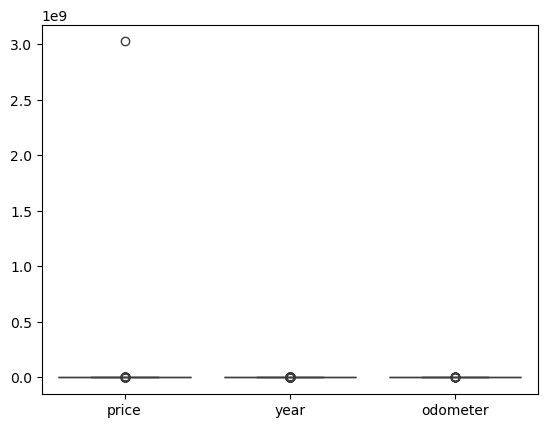

In [ ]:
sns.boxplot(data=Main_df)


In [ ]:
def find_outliers_iqr(df, columns):
    outlier_mask = pd.Series(False, index=df.index)

    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr_value = q3 - q1
        lower_bound = q1 - 1.5 * iqr_value
        upper_bound = q3 + 1.5 * iqr_value
        col_outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
        outlier_mask = outlier_mask | col_outlier_mask

    outliers_df = df[outlier_mask]
    no_outliers_df = df[~outlier_mask]

    return [outlier_mask, outliers_df, no_outliers_df]


In [ ]:
Mask = find_outliers_iqr(Main_df, numeric_columns.columns)


In [ ]:
final_df = pd.DataFrame(Mask[2])
final_df


,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color
207157,6000,2005.0,volkswagen,passat wagon,good,6 cylinders,gas,112000.0,clean,automatic,fwd,wagon,black
127272,31646,2020.0,chevrolet,blazer lt,good,6 cylinders,gas,5267.0,clean,automatic,4wd,sedan,white
403284,19797,2018.0,honda,hr-v,good,4 cylinders,gas,23024.0,clean,automatic,4wd,wagon,green
284695,7500,2010.0,honda,pilot ex-l,good,6 cylinders,gas,180000.0,clean,automatic,4wd,SUV,white
171186,11900,2012.0,honda,cr-v,excellent,4 cylinders,gas,79586.0,rebuilt,automatic,4wd,SUV,white
...,...,...,...,...,...,...,...,...,...,...,...,...,...
223955,26995,2020.0,chevrolet,equinox,good,6 cylinders,gas,31252.0,clean,automatic,4wd,SUV,black
170659,36590,2018.0,audi,q5 prestige sport utility,good,6 cylinders,gas,32409.0,clean,other,4wd,SUV,red
289197,19590,2015.0,volkswagen,golf sportwagen tdi,good,6 cylinders,other,40495.0,clean,other,fwd,wagon,white
328931,5250,2009.0,chevrolet,cobalt lt,excellent,4 cylinders,gas,81219.0,clean,automatic,fwd,sedan,blue


<Axes: >

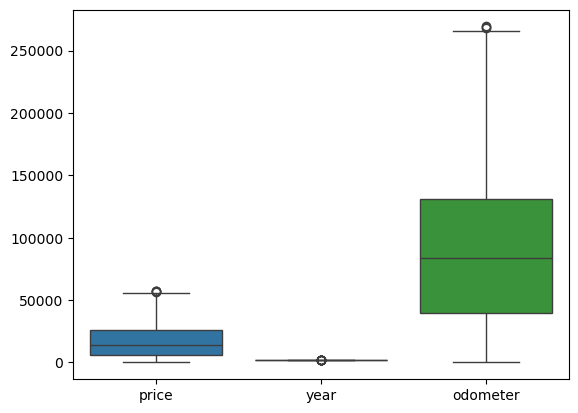

In [ ]:
sns.boxplot(data=final_df)


### Data Preparation
After our initial exploration and fine tuning of the business understanding, it is time to construct our final dataset prior to modeling. Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with sklearn.

In [ ]:
final_df["vehicle_age"] = 2025 - final_df["year"]
final_df.drop(columns=["year"], inplace=True)


In [ ]:
final_df.tail()


,price,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,vehicle_age
223955,26995,chevrolet,equinox,good,6 cylinders,gas,31252.0,clean,automatic,4wd,SUV,black,5.0
170659,36590,audi,q5 prestige sport utility,good,6 cylinders,gas,32409.0,clean,other,4wd,SUV,red,7.0
289197,19590,volkswagen,golf sportwagen tdi,good,6 cylinders,other,40495.0,clean,other,fwd,wagon,white,10.0
328931,5250,chevrolet,cobalt lt,excellent,4 cylinders,gas,81219.0,clean,automatic,fwd,sedan,blue,16.0
136989,19997,buick,encore,good,4 cylinders,gas,14541.0,clean,automatic,4wd,SUV,red,7.0


In [ ]:
final_categorical_columns = final_df.select_dtypes(include=object)


In [ ]:
final_numeric_columns = final_df.select_dtypes(include=["int64", "float64"])


# Dammy Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder


In [ ]:
encoder = OneHotEncoder(handle_unknown="ignore", drop="first")
encoded_features = encoder.fit_transform(final_categorical_columns).toarray()


In [ ]:
final_encoded_df = pd.DataFrame(
    encoded_features, columns=encoder.get_feature_names_out(encoder.feature_names_in_)
)


In [30]:
final_encoded_df.isnull().sum()


manufacturer_alfa-romeo    0
manufacturer_audi          0
manufacturer_bmw           0
manufacturer_buick         0
manufacturer_cadillac      0
                          ..
paint_color_purple         0
paint_color_red            0
paint_color_silver         0
paint_color_white          0
paint_color_yellow         0
Length: 1315, dtype: int64

In [ ]:
final_encoded_df.shape


(2355, 1315)

In [ ]:
df_numeric = final_df.drop(columns=final_categorical_columns).reset_index(drop=True)
final_main_df = pd.concat([final_encoded_df, df_numeric], axis=1).reset_index(drop=True)
final_main_df.head()


,manufacturer_alfa-romeo,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,manufacturer_chevrolet,manufacturer_chrysler,manufacturer_dodge,manufacturer_fiat,manufacturer_ford,...,paint_color_grey,paint_color_orange,paint_color_purple,paint_color_red,paint_color_silver,paint_color_white,paint_color_yellow,price,odometer,vehicle_age
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6000,112000.0,20.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,31646,5267.0,5.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19797,23024.0,7.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,7500,180000.0,15.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,11900,79586.0,13.0


In [ ]:
final_main_df.isnull().sum()


manufacturer_alfa-romeo    0
manufacturer_audi          0
manufacturer_bmw           0
manufacturer_buick         0
manufacturer_cadillac      0
                          ..
paint_color_white          0
paint_color_yellow         0
price                      0
odometer                   0
vehicle_age                0
Length: 1318, dtype: int64

In [ ]:
final_main_df.shape


(2355, 1318)

In [ ]:
final_encoded_df.dtypes


manufacturer_alfa-romeo    float64
manufacturer_audi          float64
manufacturer_bmw           float64
manufacturer_buick         float64
manufacturer_cadillac      float64
                            ...   
paint_color_purple         float64
paint_color_red            float64
paint_color_silver         float64
paint_color_white          float64
paint_color_yellow         float64
Length: 1315, dtype: object

# Featuers Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:
x_scaler = StandardScaler()
num_features = ["odometer", "vehicle_age"]
final_main_df[num_features] = x_scaler.fit_transform(final_main_df[num_features])


In [ ]:
y = pd.DataFrame(final_main_df["price"])
y


,price
0,6000
1,31646
2,19797
3,7500
4,11900
...,...
2350,26995
2351,36590
2352,19590
2353,5250


In [ ]:
y = (y - y.mean()) / y.std()
y


,price
0,-0.803613
1,1.116342
2,0.229282
3,-0.691317
4,-0.361917
...,...
2350,0.768151
2351,1.486468
2352,0.213785
2353,-0.859760


<Axes: ylabel='Count'>

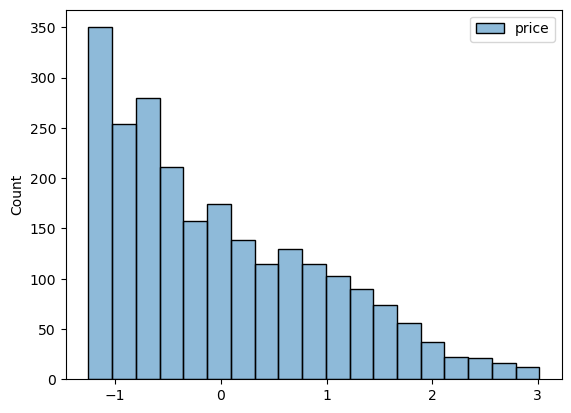

In [ ]:
sns.histplot(y)


In [ ]:
final_main_df.shape


(2355, 1318)

In [ ]:
final_main_df.head()


,manufacturer_alfa-romeo,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,manufacturer_chevrolet,manufacturer_chrysler,manufacturer_dodge,manufacturer_fiat,manufacturer_ford,...,paint_color_grey,paint_color_orange,paint_color_purple,paint_color_red,paint_color_silver,paint_color_white,paint_color_yellow,price,odometer,vehicle_age
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6000,0.364075,1.416456
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,31646,-1.442016,-1.359946
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19797,-1.141539,-0.989759
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,7500,1.514742,0.490989
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,11900,-0.184421,0.120802


## Test Train Split

In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
y = final_main_df["price"]


In [ ]:
X = final_main_df.drop(columns=["price"])
X = X.astype(np.float32)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69
)


In [ ]:
print("Final dataset shape:", final_main_df.shape)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Final dataset shape: (2355, 1318)
Training set shape: (1884, 1317)
Test set shape: (471, 1317)


In [ ]:
X_train.head()


,manufacturer_alfa-romeo,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,manufacturer_chevrolet,manufacturer_chrysler,manufacturer_dodge,manufacturer_fiat,manufacturer_ford,...,paint_color_green,paint_color_grey,paint_color_orange,paint_color_purple,paint_color_red,paint_color_silver,paint_color_white,paint_color_yellow,odometer,vehicle_age
2134,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.148883,-0.249385
1160,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.791853,-0.434478
279,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.227076,1.231363
1168,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.364075,0.861176
560,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.498925,-0.249385


### Modeling
With your (almost?) final dataset in hand, it is now time to build some models. Here, you should build a number of different regression models with the price as the target. In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
def get_train_rmse(model):
    train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, train_pred)
    rmse_train = round(np.sqrt(mse_train), 4)
    return rmse_train


def get_test_rmse(model):
    test_pred = model.predict(X_test)
    mse_test = mean_squared_error(y_test, test_pred)
    rmse_test = round(np.sqrt(mse_test), 4)
    return rmse_test


def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100


def get_test_mape(model):
    test_pred = model.predict(X_test)
    mape_test = mape(y_test, test_pred)
    return mape_test


def get_score(model):
    r_sq = model.score(X_train, y_train)
    n = X_train.shape[0]
    k = X_train.shape[1]
    r_sq_adj = 1 - ((1 - r_sq) * (n - 1) / (n - k - 1))
    return [r_sq, r_sq_adj]


In [ ]:
def plot_coefficients(model, algorithm_name):
    df_coeff = pd.DataFrame({"Variable": X.columns, "Coefficient": model.coef_})
    sorted_coeff = df_coeff.sort_values("Coefficient", ascending=False)
    sns.barplot(x="Coefficient", y="Variable", data=sorted_coeff)
    plt.xlabel("Coefficients from {}".format(algorithm_name), fontsize=15)
    plt.ylabel("Features", fontsize=15)


In [ ]:
score_card = pd.DataFrame(
    columns=[
        "Model_Name",
        "Alpha (Wherever Required)",
        "l1-ratio",
        "R-Squared",
        "Adj. R-Squared",
        "Test_RMSE",
        "Test_MAPE",
    ]
)


In [ ]:
def update_score_card(algorithm_name, model, alpha="-", l1_ratio="-"):
    global score_card
    new = pd.DataFrame(
        {
            "Model_Name": [algorithm_name],
            "Alpha (Wherever Required)": [alpha],
            "l1-ratio": [l1_ratio],
            "Test_MAPE": [get_test_mape(model)],
            "Test_RMSE": [get_test_rmse(model)],
            "R-Squared": [get_score(model)[0]],
            "Adj. R-Squared": [get_score(model)[1]],
        }
    )
    score_card = pd.concat([score_card, new], ignore_index=True)

    return score_card


In [ ]:
model = LinearRegression()
MLR_model = model.fit(X_train, y_train)
MLR_model.score(X_train, y_train)


0.8286306262016296

In [ ]:
print("RMSE on train set: ", get_train_rmse(MLR_model))
print("RMSE on test set: ", get_test_rmse(MLR_model))

difference = abs(get_test_rmse(MLR_model) - get_train_rmse(MLR_model))
print("Difference between RMSE on train and test set: ", difference)


RMSE on train set:  5563.0837
RMSE on test set:  13751.6492
Difference between RMSE on train and test set:  8188.5655


In [ ]:
score_card = update_score_card(algorithm_name="Linear Regression", model=MLR_model)
score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.828631,0.429879,13751.6492,inf


# Stochastic Gradient Descent

In [ ]:
from sklearn.linear_model import SGDRegressor


In [ ]:
sgd = SGDRegressor()
linreg_with_sgd = sgd.fit(X_train, y_train)
print("RMSE on train set:", get_train_rmse(linreg_with_sgd))
print("RMSE on test set:", get_test_rmse(linreg_with_sgd))


RMSE on train set: 8346.304
RMSE on test set: 9740.3008


In [ ]:
score_card = update_score_card(
    algorithm_name="Linear Regression (using SGD)", model=linreg_with_sgd
)
score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.828631,0.429879,13751.6492,inf
1,Linear Regression (using SGD),-,-,0.614264,-0.283289,9740.3008,inf


# . Regularization

## Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge


In [ ]:
ridge = Ridge(alpha=1, max_iter=500)
ridge.fit(X_train, y_train)
print("RMSE on test set:", get_test_rmse(ridge))


RMSE on test set: 9852.1186


In [ ]:
score_card = update_score_card(
    algorithm_name="Ridge Regression (with alpha = 1)", model=ridge, alpha=1
)
score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.828631,0.429879,13751.6492,inf
1,Linear Regression (using SGD),-,-,0.614264,-0.283289,9740.3008,inf
2,Ridge Regression (with alpha = 1),1,-,0.746633,0.157086,9852.1186,inf


In [ ]:
ridge = Ridge(alpha=2, max_iter=500)
ridge.fit(X_train, y_train)
print("RMSE on test set:", get_test_rmse(ridge))


RMSE on test set: 9758.2794


In [ ]:
score_card = update_score_card(
    algorithm_name="Ridge Regression (with alpha = 2)", model=ridge, alpha=2
)
score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.828631,0.429879,13751.6492,inf
1,Linear Regression (using SGD),-,-,0.614264,-0.283289,9740.3008,inf
2,Ridge Regression (with alpha = 1),1,-,0.746633,0.157086,9852.1186,inf
3,Ridge Regression (with alpha = 2),2,-,0.689443,-0.033179,9758.2794,inf


## Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso


In [ ]:
lasso = Lasso()
lasso.fit(X_train, y_train)
print("RMSE on test set:", get_test_rmse(lasso))


RMSE on test set: 10279.1867


In [ ]:
score_card = update_score_card(
    algorithm_name="Lasso Regression", model=lasso, alpha="0.01"
)
score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.828631,0.429879,13751.6492,inf
1,Linear Regression (using SGD),-,-,0.614264,-0.283289,9740.3008,inf
2,Ridge Regression (with alpha = 1),1,-,0.746633,0.157086,9852.1186,inf
3,Ridge Regression (with alpha = 2),2,-,0.689443,-0.033179,9758.2794,inf
4,Lasso Regression,0.01,-,0.810426,0.369315,10279.1867,inf


## Elastic Net Regression

In [ ]:
from sklearn.linear_model import ElasticNet


In [ ]:
enet = ElasticNet()
enet.fit(X_train, y_train)
print("RMSE on test set:", get_test_rmse(enet))


RMSE on test set: 10569.2335


In [ ]:
score_card = update_score_card(
    algorithm_name="Elastic Net Regression", model=enet, alpha="0.1", l1_ratio="0.01"
)
score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.828631,0.429879,13751.6492,inf
1,Linear Regression (using SGD),-,-,0.614264,-0.283289,9740.3008,inf
2,Ridge Regression (with alpha = 1),1,-,0.746633,0.157086,9852.1186,inf
3,Ridge Regression (with alpha = 2),2,-,0.689443,-0.033179,9758.2794,inf
4,Lasso Regression,0.01,-,0.810426,0.369315,10279.1867,inf
5,Elastic Net Regression,0.1,0.01,0.351307,-1.158109,10569.2335,inf


In [ ]:
score_card = score_card.sort_values("Test_RMSE").reset_index(drop=True)

score_card.style.highlight_min(color="lightblue", subset="Test_RMSE")


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression (using SGD),-,-,0.614264,-0.283289,9740.300800,inf
1,Ridge Regression (with alpha = 2),2,-,0.689443,-0.033179,9758.279400,inf
2,Ridge Regression (with alpha = 1),1,-,0.746633,0.157086,9852.118600,inf
3,Lasso Regression,0.01,-,0.810426,0.369315,10279.186700,inf
4,Elastic Net Regression,0.1,0.01,0.351307,-1.158109,10569.233500,inf
5,Linear Regression,-,-,0.828631,0.429879,13751.649200,inf
